# Demand Forecasting - Pipeline de Modelos
Comparacion de **Prophet**, **LightGBM** y **XGBoost** para prediccion de demanda diaria agregada.

| Seccion | Contenido |
|---|---|
| 1 | Carga y preprocesamiento |
| 2 | Feature Engineering |
| 3 | Division Train / Test |
| 4 | Modelo 1 - Prophet |
| 5 | Modelo 2 - LightGBM |
| 6 | Modelo 3 - XGBoost |
| 7 | Comparacion final |

In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from itertools import product

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from scipy.stats import randint, uniform

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (13, 5)
RANDOM_STATE = 42

## 1. Carga y Preprocesamiento

In [153]:
df = pd.read_csv('demand_forecasting.csv')
df['Date'] = pd.to_datetime(df['Date'])
print(f'Shape: {df.shape}')
print(f'Rango: {df.Date.min().date()} -> {df.Date.max().date()}')
df.head(3)

Shape: (76000, 16)
Rango: 2022-01-01 -> 2024-01-30


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157


In [154]:
# Weather es nominal: one-hot encoding (Cloudy = referencia al ordenar alfabeticamente)
weather_daily = (
    df.groupby('Date')['Weather Condition']
    .agg(lambda x: x.mode()[0])
    .rename('Weather')
)

# Price relativo a la media de la categoria (captura posicion de precio dentro del segmento)
df['price_vs_cat_mean'] = df['Price'] / df.groupby('Category')['Price'].transform('mean')

daily = df.groupby('Date').agg(
    Demand            = ('Demand',             'sum'),
    # Units_Sold excluido: data leakage (correlacion 0.83 con Demand)
    # Units_Ordered excluido: posible data leakage
    Promotion_Ratio   = ('Promotion',          'mean'),
    Epidemic          = ('Epidemic',           'max'),
    Avg_Discount      = ('Discount',           'mean'),
    Avg_Price         = ('Price',              'mean'),
    Avg_Competitor    = ('Competitor Pricing', 'mean'),
    Price_vs_Cat_Mean = ('price_vs_cat_mean',  'mean'),
    Avg_Inventory     = ('Inventory Level',    'mean'),
).reset_index()

daily = daily.merge(weather_daily.reset_index(), on='Date').sort_values('Date').reset_index(drop=True)

# Lag de epidemia: el modelo no asume conocimiento futuro de si habra epidemia
daily['epidemic_lag_7'] = daily['Epidemic'].shift(7).fillna(0).astype(int)

# One-hot encoding del clima
weather_dummies = pd.get_dummies(daily['Weather'], prefix='weather', drop_first=True, dtype=int)
daily = pd.concat([daily.drop(columns=['Weather', 'Epidemic']), weather_dummies], axis=1)

print(f'Serie diaria: {daily.shape}')
print(f'Columnas de clima: {[c for c in daily.columns if c.startswith("weather")]}')
daily.head()

Serie diaria: (760, 12)
Columnas de clima: ['weather_Rainy', 'weather_Snowy', 'weather_Sunny']


,Date,Demand,Promotion_Ratio,Avg_Discount,Avg_Price,Avg_Competitor,Price_vs_Cat_Mean,Avg_Inventory,epidemic_lag_7,weather_Rainy,weather_Snowy,weather_Sunny
0,2022-01-01,10060,0.15,6.45,68.6690,70.8500,1.013936,193.83,0,0,1,0
1,2022-01-02,10814,0.20,7.35,70.3806,72.4986,1.032794,123.85,0,0,0,0
2,2022-01-03,11317,0.35,9.15,69.7910,72.1262,1.031464,103.56,0,0,0,0
3,2022-01-04,11469,0.45,10.30,69.8443,72.0545,1.023116,180.71,0,0,0,0
4,2022-01-05,11724,0.70,14.35,66.8190,68.6097,0.986147,271.52,0,0,1,0


## 2. Feature Engineering
Features de calendario, lags y medias moviles para LightGBM y XGBoost.
Prophet usa directamente los regressors externos.

In [155]:
def create_features(df):
    df = df.copy()
    # Calendario (dayofweek excluido: rango de solo 1.8 unidades entre dias, agrega ruido)
    df['month']      = df['Date'].dt.month
    df['quarter']    = df['Date'].dt.quarter
    df['weekofyear'] = df['Date'].dt.isocalendar().week.astype(int)
    df['is_weekend'] = (df['Date'].dt.dayofweek >= 5).astype(int)

    # Lags sobre Demand original (antes de log1p, para que los lags sean interpretables)
    for lag in [1, 7, 14, 30]:
        df[f'lag_{lag}'] = df['Demand'].shift(lag)

    for w in [7, 14, 30]:
        df[f'rolling_mean_{w}'] = df['Demand'].shift(1).rolling(w).mean()
        df[f'rolling_std_{w}']  = df['Demand'].shift(1).rolling(w).std()

    # Log del inventario: reduce el efecto de valores extremos (max=2267 vs mean=301)
    df['log_inventory'] = np.log1p(df['Avg_Inventory'])

    # Interaccion Promotion x Epidemic (lag): captura efecto combinado
    df['promo_x_epidemic'] = df['Promotion_Ratio'] * df['epidemic_lag_7']

    # Aplicar log1p al target para reducir impacto de outliers (max=14093, p99=13428)
    df['Demand_log'] = np.log1p(df['Demand'])

    return df

daily = create_features(daily).dropna().reset_index(drop=True)
print(f'Shape tras feature engineering: {daily.shape}')
daily[['Demand', 'Demand_log']].describe().round(2)

Shape tras feature engineering: (730, 29)


,Demand,Demand_log
count,730.00,730.00
mean,10406.28,9.23
std,1926.48,0.21
min,5859.00,8.68
25%,9875.75,9.20
50%,10977.00,9.30
75%,11750.00,9.37
max,14093.00,9.55


## 3. Division Train / Test
- **Train**: 2022-01 a 2023-10 (~22 meses)
- **Test**: 2023-11 a 2024-01 (~3 meses)

In [156]:
CUTOFF = '2023-10-31'

train = daily[daily['Date'] <= CUTOFF].reset_index(drop=True)
test  = daily[daily['Date'] >  CUTOFF].reset_index(drop=True)

print(f'Train: {train.Date.min().date()} -> {train.Date.max().date()}  ({len(train)} dias)')
print(f'Test:  {test.Date.min().date()} -> {test.Date.max().date()}  ({len(test)} dias)')

FEATURES = [
    # Calendario (dayofweek excluido por bajo poder predictivo)
    'month', 'quarter', 'weekofyear', 'is_weekend',
    # Lags y rolling
    'lag_1', 'lag_7', 'lag_14', 'lag_30',
    'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30',
    'rolling_std_7', 'rolling_std_14', 'rolling_std_30',
    # Variables externas
    'Promotion_Ratio',
    'epidemic_lag_7',       # Epidemic con lag de 7 dias (evita data leakage futuro)
    'Avg_Discount',         # Discount captura tanto nivel de descuento como presencia de promo
    'Avg_Price',
    'Price_vs_Cat_Mean',    # Precio relativo a categoria (captura posicion competitiva interna)
    'log_inventory',        # Inventario en escala log (reduce efecto de extremos)
    'promo_x_epidemic',     # Interaccion: efecto de promo durante epidemia
    # Clima (one-hot, Cloudy = referencia)
    'weather_Rainy', 'weather_Snowy', 'weather_Sunny',
]
TARGET     = 'Demand_log'   # Entrenamos en escala log para reducir impacto de outliers
TARGET_RAW = 'Demand'       # Para calcular metricas en escala original

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET_RAW]   # metricas siempre en escala original

results_list = []

def evaluate(y_true_raw, y_pred_log, model_name):
    # Invertir log1p para comparar en escala original
    y_pred_raw = np.expm1(y_pred_log).clip(0)
    mae  = mean_absolute_error(y_true_raw, y_pred_raw)
    rmse = np.sqrt(mean_squared_error(y_true_raw, y_pred_raw))
    mape = mean_absolute_percentage_error(y_true_raw, y_pred_raw) * 100
    row  = {'Modelo': model_name, 'MAE': round(mae,1), 'RMSE': round(rmse,1), 'MAPE (%)': round(mape,2)}
    results_list.append(row)
    print(f'{model_name:<12}  MAE={mae:.1f}  RMSE={rmse:.1f}  MAPE={mape:.2f}%')
    return y_pred_raw

Train: 2022-01-31 -> 2023-10-31  (639 dias)
Test:  2023-11-01 -> 2024-01-30  (91 dias)


## 4. Modelo 1 - Prophet

### 4.1 Preparacion de datos

In [157]:
# Prophet no usa log1p (maneja el target directamente y tiene su propio manejo de escala)
# Epidemic reemplazado por epidemic_lag_7; Promotion_Ratio captura ya la info de Discount
REGRESSORS = ['Promotion_Ratio', 'epidemic_lag_7', 'Avg_Discount','Avg_Price', 'promo_x_epidemic']

prophet_train = train[['Date', TARGET_RAW] + REGRESSORS].rename(columns={'Date': 'ds', TARGET_RAW: 'y'})
prophet_test  = test[['Date',  TARGET_RAW] + REGRESSORS].rename(columns={'Date': 'ds', TARGET_RAW: 'y'})

prophet_train.head(3)

,ds,y,Promotion_Ratio,epidemic_lag_7,Avg_Discount,Avg_Price,promo_x_epidemic
0,2022-01-31,10028,0.0,0,5.30,70.4056,0.0
1,2022-02-01,10791,0.5,0,10.85,67.2877,0.0
2,2022-02-02,12698,0.5,0,11.70,69.8447,0.0


### 4.2 Busqueda de hiperparametros (Grid Search + CV temporal)
18 combinaciones x validacion cruzada. Puede tardar 5-10 minutos.

In [158]:
param_grid = {
    'changepoint_prior_scale': [0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.1, 1.0, 10.0],
    'seasonality_mode':        ['additive', 'multiplicative'],
}

all_params = [dict(zip(param_grid, v)) for v in product(*param_grid.values())]
print(f'Evaluando {len(all_params)} combinaciones...')

prophet_cv_results = []

for i, params in enumerate(all_params):
    try:
        m = Prophet(weekly_seasonality=True, yearly_seasonality=True,
                    daily_seasonality=False, **params)
        for reg in REGRESSORS:
            m.add_regressor(reg)
        m.fit(prophet_train)
        # initial >= 365.25 dias para que la estacionalidad anual pueda entrenarse
        cv_df = cross_validation(m, initial='400 days', period='30 days',
                                 horizon='60 days', disable_tqdm=True)
        perf = performance_metrics(cv_df, rolling_window=1)
        mae  = perf['mae'].mean()
        prophet_cv_results.append({'params': params, 'mae': mae})
        print(f'  [{i+1:>2}/{len(all_params)}] MAE={mae:.1f}  {params}')
    except Exception as e:
        print(f'  [{i+1:>2}/{len(all_params)}] ERROR: {e}')

if not prophet_cv_results:
    raise RuntimeError('Todas las combinaciones fallaron.')

best_prophet_params = min(prophet_cv_results, key=lambda x: x['mae'])
print(f'\nMejores hiperparametros: {best_prophet_params["params"]}')
print(f'MAE CV: {best_prophet_params["mae"]:.1f}')

Evaluando 18 combinaciones...


19:20:36 - cmdstanpy - INFO - Chain [1] start processing
19:20:36 - cmdstanpy - INFO - Chain [1] done processing
19:20:36 - cmdstanpy - INFO - Chain [1] start processing
19:20:36 - cmdstanpy - INFO - Chain [1] done processing
19:20:36 - cmdstanpy - INFO - Chain [1] start processing
19:20:36 - cmdstanpy - INFO - Chain [1] done processing
19:20:36 - cmdstanpy - INFO - Chain [1] start processing
19:20:36 - cmdstanpy - INFO - Chain [1] done processing
19:20:36 - cmdstanpy - INFO - Chain [1] start processing
19:20:37 - cmdstanpy - INFO - Chain [1] done processing
19:20:37 - cmdstanpy - INFO - Chain [1] start processing
19:20:37 - cmdstanpy - INFO - Chain [1] done processing
19:20:37 - cmdstanpy - INFO - Chain [1] start processing
19:20:37 - cmdstanpy - INFO - Chain [1] done processing
19:20:37 - cmdstanpy - INFO - Chain [1] start processing
19:20:37 - cmdstanpy - INFO - Chain [1] done processing


  [ 1/18] MAE=246.2  {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.1, 'seasonality_mode': 'additive'}


19:20:37 - cmdstanpy - INFO - Chain [1] start processing
19:20:37 - cmdstanpy - INFO - Chain [1] done processing
19:20:38 - cmdstanpy - INFO - Chain [1] start processing
19:20:38 - cmdstanpy - INFO - Chain [1] done processing
19:20:38 - cmdstanpy - INFO - Chain [1] start processing
19:20:38 - cmdstanpy - INFO - Chain [1] done processing
19:20:38 - cmdstanpy - INFO - Chain [1] start processing
19:20:38 - cmdstanpy - INFO - Chain [1] done processing
19:20:38 - cmdstanpy - INFO - Chain [1] start processing
19:20:38 - cmdstanpy - INFO - Chain [1] done processing
19:20:39 - cmdstanpy - INFO - Chain [1] start processing
19:20:39 - cmdstanpy - INFO - Chain [1] done processing
19:20:39 - cmdstanpy - INFO - Chain [1] start processing
19:20:39 - cmdstanpy - INFO - Chain [1] done processing


  [ 2/18] MAE=248.8  {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.1, 'seasonality_mode': 'multiplicative'}


...

  [16/18] MAE=386.4  {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'multiplicative'}


19:21:15 - cmdstanpy - INFO - Chain [1] done processing
19:21:15 - cmdstanpy - INFO - Chain [1] start processing
19:21:16 - cmdstanpy - INFO - Chain [1] done processing
19:21:16 - cmdstanpy - INFO - Chain [1] start processing
19:21:16 - cmdstanpy - INFO - Chain [1] done processing
19:21:16 - cmdstanpy - INFO - Chain [1] start processing
19:21:16 - cmdstanpy - INFO - Chain [1] done processing
19:21:16 - cmdstanpy - INFO - Chain [1] start processing
19:21:16 - cmdstanpy - INFO - Chain [1] done processing
19:21:17 - cmdstanpy - INFO - Chain [1] start processing
19:21:17 - cmdstanpy - INFO - Chain [1] done processing
19:21:17 - cmdstanpy - INFO - Chain [1] start processing
19:21:17 - cmdstanpy - INFO - Chain [1] done processing
19:21:17 - cmdstanpy - INFO - Chain [1] start processing


  [17/18] MAE=309.0  {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'additive'}


19:21:18 - cmdstanpy - INFO - Chain [1] done processing
19:21:18 - cmdstanpy - INFO - Chain [1] start processing
19:21:18 - cmdstanpy - INFO - Chain [1] done processing
19:21:18 - cmdstanpy - INFO - Chain [1] start processing
19:21:18 - cmdstanpy - INFO - Chain [1] done processing
19:21:18 - cmdstanpy - INFO - Chain [1] start processing
19:21:18 - cmdstanpy - INFO - Chain [1] done processing
19:21:19 - cmdstanpy - INFO - Chain [1] start processing
19:21:19 - cmdstanpy - INFO - Chain [1] done processing
19:21:19 - cmdstanpy - INFO - Chain [1] start processing
19:21:19 - cmdstanpy - INFO - Chain [1] done processing
19:21:19 - cmdstanpy - INFO - Chain [1] start processing
19:21:19 - cmdstanpy - INFO - Chain [1] done processing


  [18/18] MAE=380.4  {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'multiplicative'}

Mejores hiperparametros: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'additive'}
MAE CV: 243.8


### 4.3 Modelo final y predicciones

In [159]:
prophet_model = Prophet(
    weekly_seasonality=True, yearly_seasonality=True,
    daily_seasonality=False,
    **best_prophet_params['params']
)
for reg in REGRESSORS:
    prophet_model.add_regressor(reg)

prophet_model.fit(prophet_train)

future   = prophet_test[['ds'] + REGRESSORS].copy()
forecast = prophet_model.predict(future)

# Prophet predice en escala original directamente
prophet_preds_raw = forecast['yhat'].clip(lower=0).values
prophet_preds_log = np.log1p(prophet_preds_raw)   # para evaluate uniforme

prophet_preds = evaluate(y_test, prophet_preds_log, 'Prophet')

19:21:20 - cmdstanpy - INFO - Chain [1] start processing
19:21:20 - cmdstanpy - INFO - Chain [1] done processing


Prophet       MAE=205.4  RMSE=263.4  MAPE=2.00%


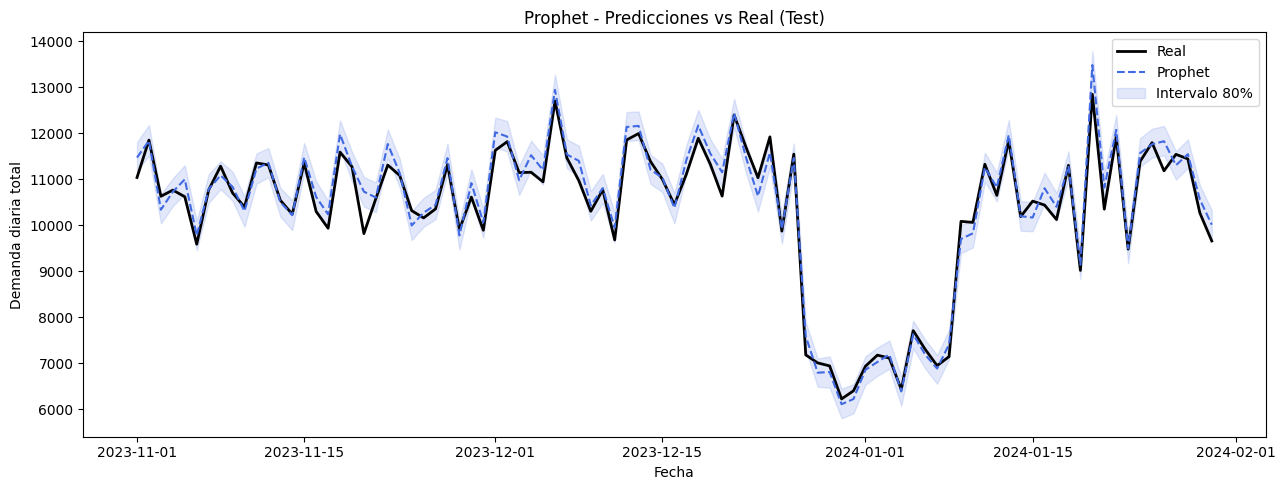

In [160]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test['Date'], y_test,        label='Real',       color='black',     linewidth=2)
ax.plot(test['Date'], prophet_preds, label='Prophet',    color='royalblue', linestyle='--')
ax.fill_between(test['Date'],
                forecast['yhat_lower'].clip(0).values,
                forecast['yhat_upper'].values,
                alpha=0.15, color='royalblue', label='Intervalo 80%')
ax.set_title('Prophet - Predicciones vs Real (Test)')
ax.set_xlabel('Fecha'); ax.set_ylabel('Demanda diaria total')
ax.legend(); plt.tight_layout(); plt.show()

## 5. Modelo 2 - LightGBM

### 5.1 Busqueda de hiperparametros (RandomizedSearchCV + TimeSeriesSplit)

In [161]:
lgb_param_dist = {
    'n_estimators':      randint(200, 700),
    'max_depth':         randint(3, 9),
    'learning_rate':     uniform(0.01, 0.14),
    'num_leaves':        randint(20, 150),
    'subsample':         uniform(0.7, 0.3),
    'colsample_bytree':  uniform(0.7, 0.3),
    'reg_alpha':         uniform(0, 1),
    'reg_lambda':        uniform(0, 1),
    'min_child_samples': randint(10, 50),
}

tscv = TimeSeriesSplit(n_splits=5)

lgb_search = RandomizedSearchCV(
    LGBMRegressor(random_state=RANDOM_STATE, verbose=-1),
    param_distributions=lgb_param_dist,
    n_iter=40,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

lgb_search.fit(X_train, y_train)
print('\nMejores hiperparametros LightGBM:')
for k, v in lgb_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'MAE CV: {-lgb_search.best_score_:.1f}')

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Mejores hiperparametros LightGBM:
  colsample_bytree: 0.7585728963394133
  learning_rate: 0.11114329613661075
  max_depth: 5
  min_child_samples: 13
  n_estimators: 234
  num_leaves: 68
  reg_alpha: 0.04360377175443375
  reg_lambda: 0.994550510797341
  subsample: 0.8409833541972829
MAE CV: 0.0


### 5.2 Modelo final, predicciones e importancia de features

LightGBM      MAE=202.4  RMSE=255.6  MAPE=2.06%


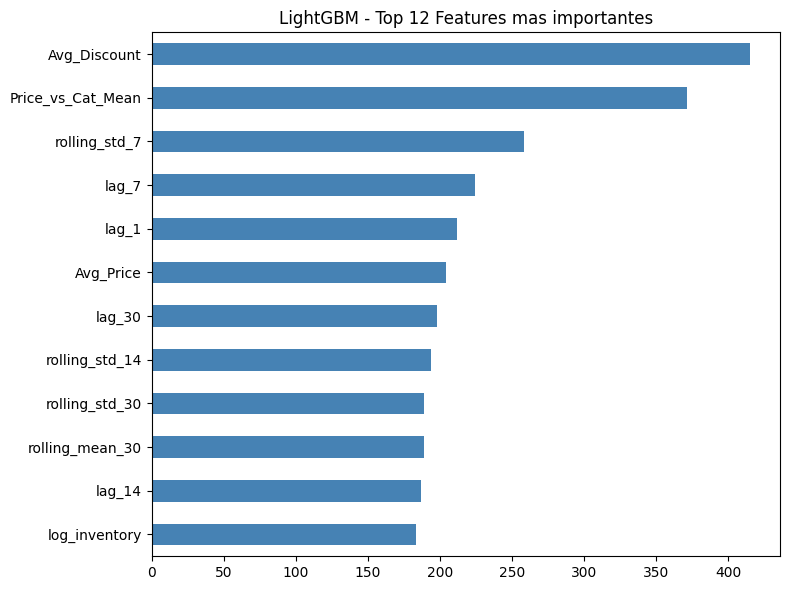

In [162]:
lgb_model = lgb_search.best_estimator_
lgb_preds = evaluate(y_test, lgb_model.predict(X_test), 'LightGBM')

feat_imp_lgb = pd.Series(lgb_model.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp_lgb.tail(12).plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('LightGBM - Top 12 Features mas importantes')
plt.tight_layout(); plt.show()

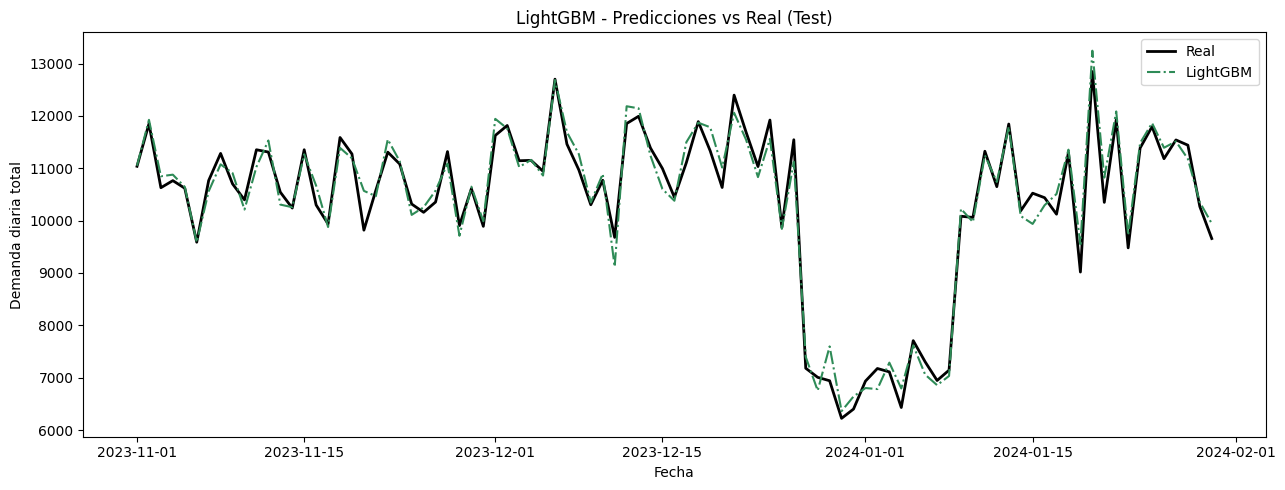

In [163]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test['Date'], y_test,    label='Real',     color='black',    linewidth=2)
ax.plot(test['Date'], lgb_preds, label='LightGBM', color='seagreen', linestyle='-.')
ax.set_title('LightGBM - Predicciones vs Real (Test)')
ax.set_xlabel('Fecha'); ax.set_ylabel('Demanda diaria total')
ax.legend(); plt.tight_layout(); plt.show()

## 6. Modelo 3 - XGBoost

### 6.1 Busqueda de hiperparametros

In [164]:
xgb_param_dist = {
    'n_estimators':     randint(200, 700),
    'max_depth':        randint(3, 9),
    'learning_rate':    uniform(0.01, 0.14),
    'subsample':        uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'reg_alpha':        uniform(0, 1),
    'reg_lambda':       uniform(0, 1),
    'gamma':            uniform(0, 0.5),
    'min_child_weight': randint(1, 10),
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, verbosity=0, tree_method='hist'),
    param_distributions=xgb_param_dist,
    n_iter=40,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

xgb_search.fit(X_train, y_train)
print('\nMejores hiperparametros XGBoost:')
for k, v in xgb_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'MAE CV: {-xgb_search.best_score_:.1f}')

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Mejores hiperparametros XGBoost:
  colsample_bytree: 0.8943070361624086
  gamma: 0.0002601884976579094
  learning_rate: 0.059359639886783666
  max_depth: 5
  min_child_weight: 7
  n_estimators: 397
  reg_alpha: 0.5107473025775657
  reg_lambda: 0.417411003148779
  subsample: 0.766632343141219
MAE CV: 0.0


### 6.2 Modelo final, predicciones e importancia de features

XGBoost       MAE=218.8  RMSE=289.2  MAPE=2.22%


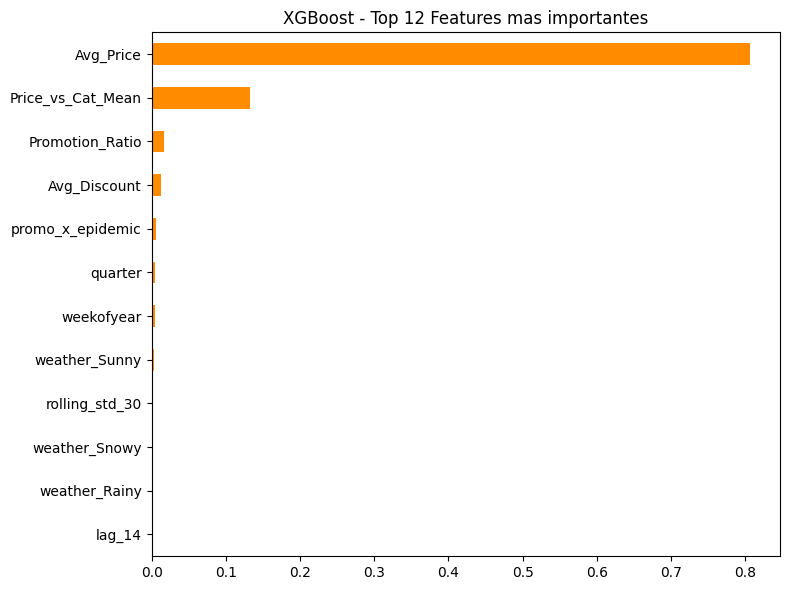

In [165]:
xgb_model = xgb_search.best_estimator_
xgb_preds = evaluate(y_test, xgb_model.predict(X_test), 'XGBoost')

feat_imp_xgb = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp_xgb.tail(12).plot(kind='barh', color='darkorange', ax=ax)
ax.set_title('XGBoost - Top 12 Features mas importantes')
plt.tight_layout(); plt.show()

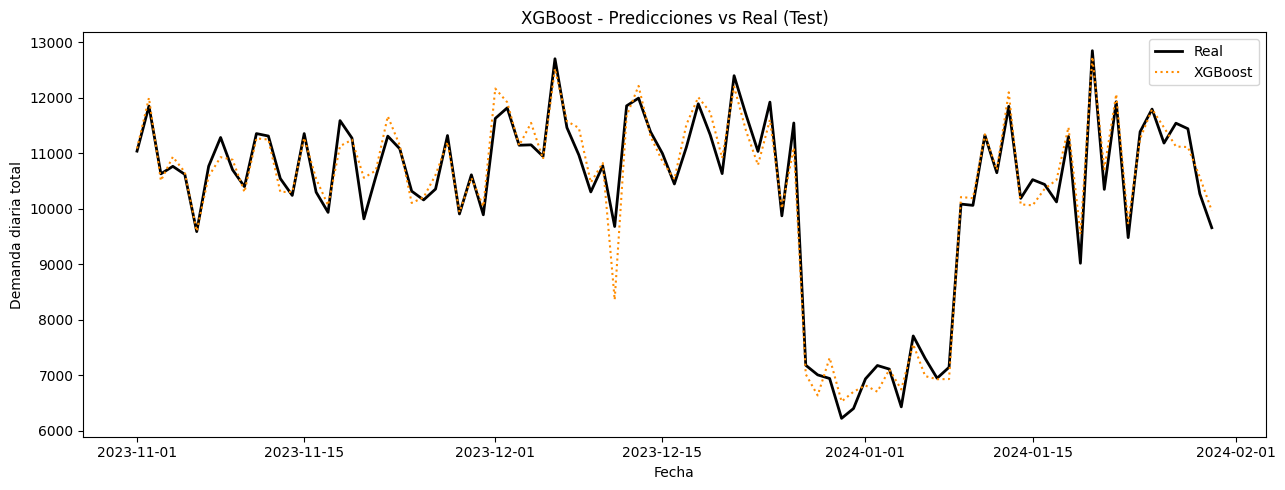

In [166]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test['Date'], y_test,    label='Real',    color='black',      linewidth=2)
ax.plot(test['Date'], xgb_preds, label='XGBoost', color='darkorange', linestyle=':')
ax.set_title('XGBoost - Predicciones vs Real (Test)')
ax.set_xlabel('Fecha'); ax.set_ylabel('Demanda diaria total')
ax.legend(); plt.tight_layout(); plt.show()

## 7. Comparacion Final de Modelos

In [167]:
results_df = pd.DataFrame(results_list).set_index('Modelo')
print('=== METRICAS EN TEST ===')
print(results_df.to_string())
results_df.style.highlight_min(color='lightgreen', axis=0).highlight_max(color='#ffcccc', axis=0)

=== METRICAS EN TEST ===
            MAE   RMSE  MAPE (%)
Modelo                          
Prophet   205.4  263.4      2.00
LightGBM  202.4  255.6      2.06
XGBoost   218.8  289.2      2.22


,MAE,RMSE,MAPE (%)
Modelo,,,
Prophet,205.400000,263.400000,2.000000
LightGBM,202.400000,255.600000,2.060000
XGBoost,218.800000,289.200000,2.220000


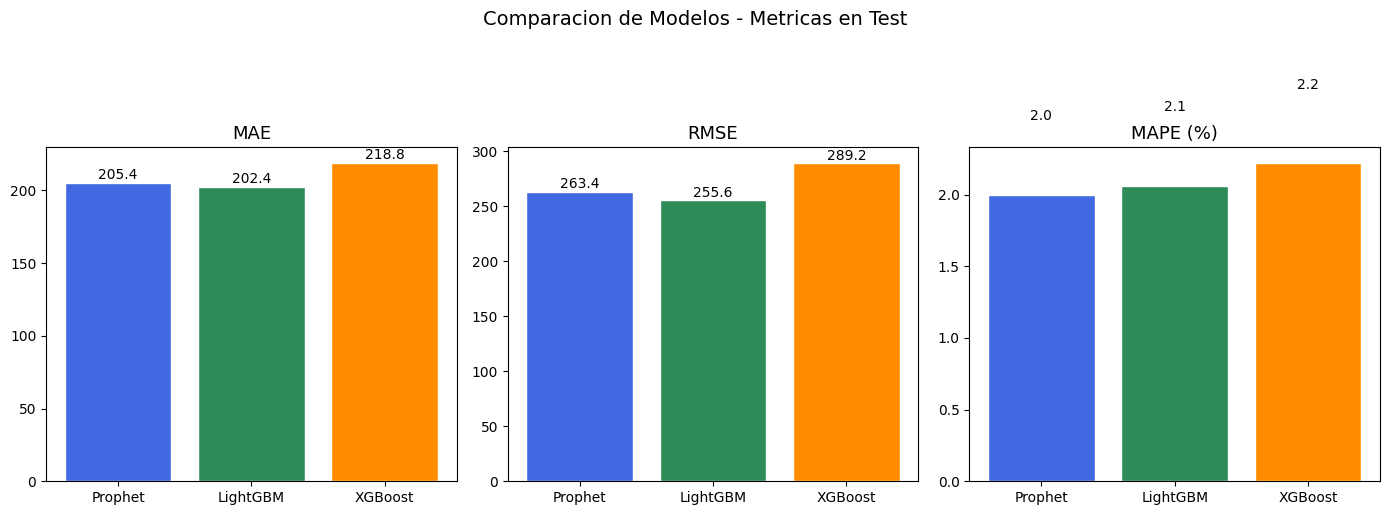

In [168]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ['royalblue', 'seagreen', 'darkorange']

for i, metric in enumerate(['MAE', 'RMSE', 'MAPE (%)']):
    bars = axes[i].bar(results_df.index, results_df[metric], color=colors, edgecolor='white')
    axes[i].set_title(metric, fontsize=13)
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                     f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Comparacion de Modelos - Metricas en Test', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

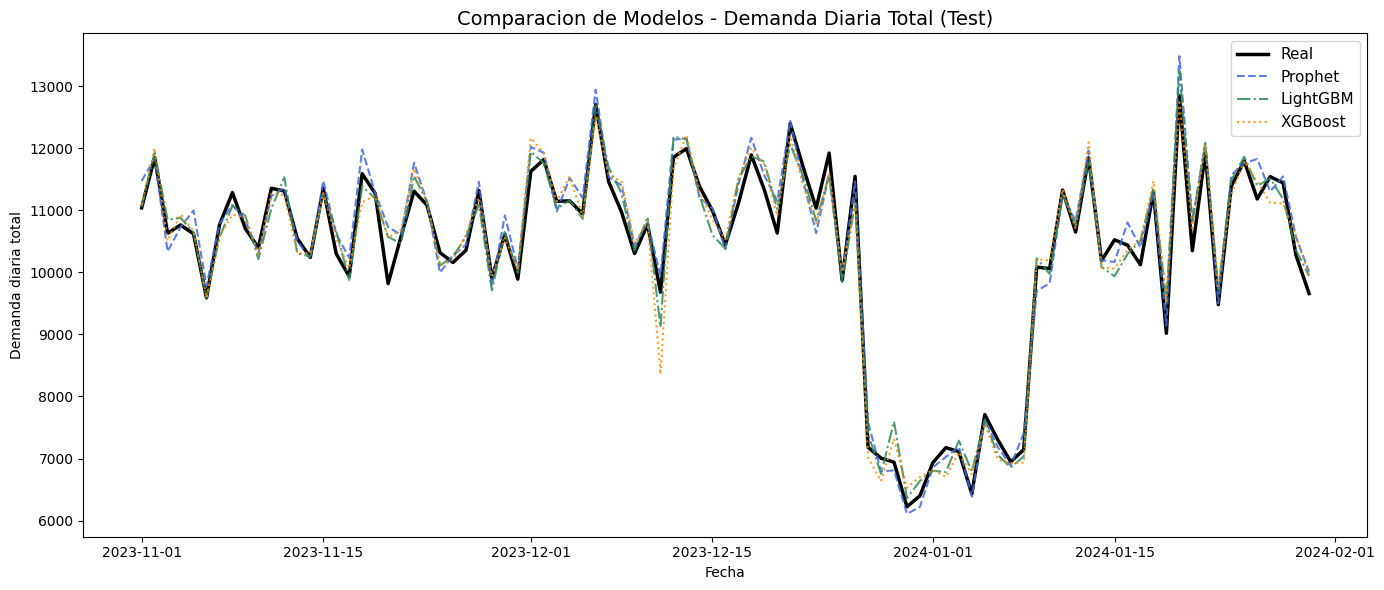

In [169]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test['Date'], y_test,        label='Real',     color='black',      linewidth=2.5)
ax.plot(test['Date'], prophet_preds, label='Prophet',  color='royalblue',  linestyle='--',  alpha=0.85)
ax.plot(test['Date'], lgb_preds,     label='LightGBM', color='seagreen',   linestyle='-.',  alpha=0.85)
ax.plot(test['Date'], xgb_preds,     label='XGBoost',  color='darkorange', linestyle=':',   alpha=0.85)
ax.set_title('Comparacion de Modelos - Demanda Diaria Total (Test)', fontsize=14)
ax.set_xlabel('Fecha'); ax.set_ylabel('Demanda diaria total')
ax.legend(fontsize=11)
plt.tight_layout(); plt.show()

## Conclusiones

| Modelo | Fortalezas | Limitaciones |
|---|---|---|
| **Prophet** | Interpretable, intervalos de confianza, captura estacionalidad | No captura interacciones; lento en tuning |
| **LightGBM** | Muy preciso, rapido, aprende interacciones complejas | Requiere feature engineering (lags) |
| **XGBoost** | Robusto, buen manejo de outliers | Similar a LightGBM; algo mas lento |

El modelo con menor error en test es el candidato para produccion. Si la interpretabilidad es prioritaria, Prophet es la mejor opcion de baseline.

## 8. Análisis de Residuos

Un buen modelo produce residuos que son **ruido blanco**: sin tendencia, sin autocorrelación y sin estructura asociada a las features. Si los residuos tienen patrones, significa que el modelo dejó información sin capturar.

| Prueba | Qué detecta |
|---|---|
| Residuos en el tiempo | Tendencia o ciclos sistemáticos |
| ACF de residuos | Autocorrelación (patrones temporales no capturados) |
| Test Ljung-Box | Test formal de ruido blanco |
| Residuos vs features | Efectos no lineales no capturados |
| Distribución | Sesgo sistemático (modelo sobre/subestima) |

### 8.1 Construcción del DataFrame de residuos

In [170]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import shapiro, probplot

residuals = pd.DataFrame({
    'Date':    test['Date'].values,
    'Real':    y_test.values,
    'Prophet': prophet_preds,
    'LightGBM': lgb_preds,
    'XGBoost':  xgb_preds,
})

# Residuos = Real - Prediccion (positivo = modelo subestima, negativo = sobreestima)
for model in ['Prophet', 'LightGBM', 'XGBoost']:
    residuals[f'resid_{model}'] = residuals['Real'] - residuals[model]

# Features del test para analizar residuos vs variables
residuals['epidemic_lag_7']  = test['epidemic_lag_7'].values
residuals['Promotion_Ratio'] = test['Promotion_Ratio'].values
residuals['month']           = test['month'].values

print('Estadisticas de residuos:')
resid_cols = [c for c in residuals.columns if c.startswith('resid_')]
print(residuals[resid_cols].describe().round(1))

Estadisticas de residuos:
       resid_Prophet  resid_LightGBM  resid_XGBoost
count           91.0            91.0           91.0
mean           -90.6           -28.0          -20.5
std            248.7           255.5          290.0
min           -912.5          -750.5         -739.6
25%           -272.8          -212.4         -200.5
50%            -75.2           -11.1          -40.5
75%             77.9           138.2          134.5
max            399.3           586.6         1320.2


### 8.2 Residuos en el tiempo
Si hay tendencia, ciclos o cambios de nivel → el modelo dejó estructura temporal sin capturar.

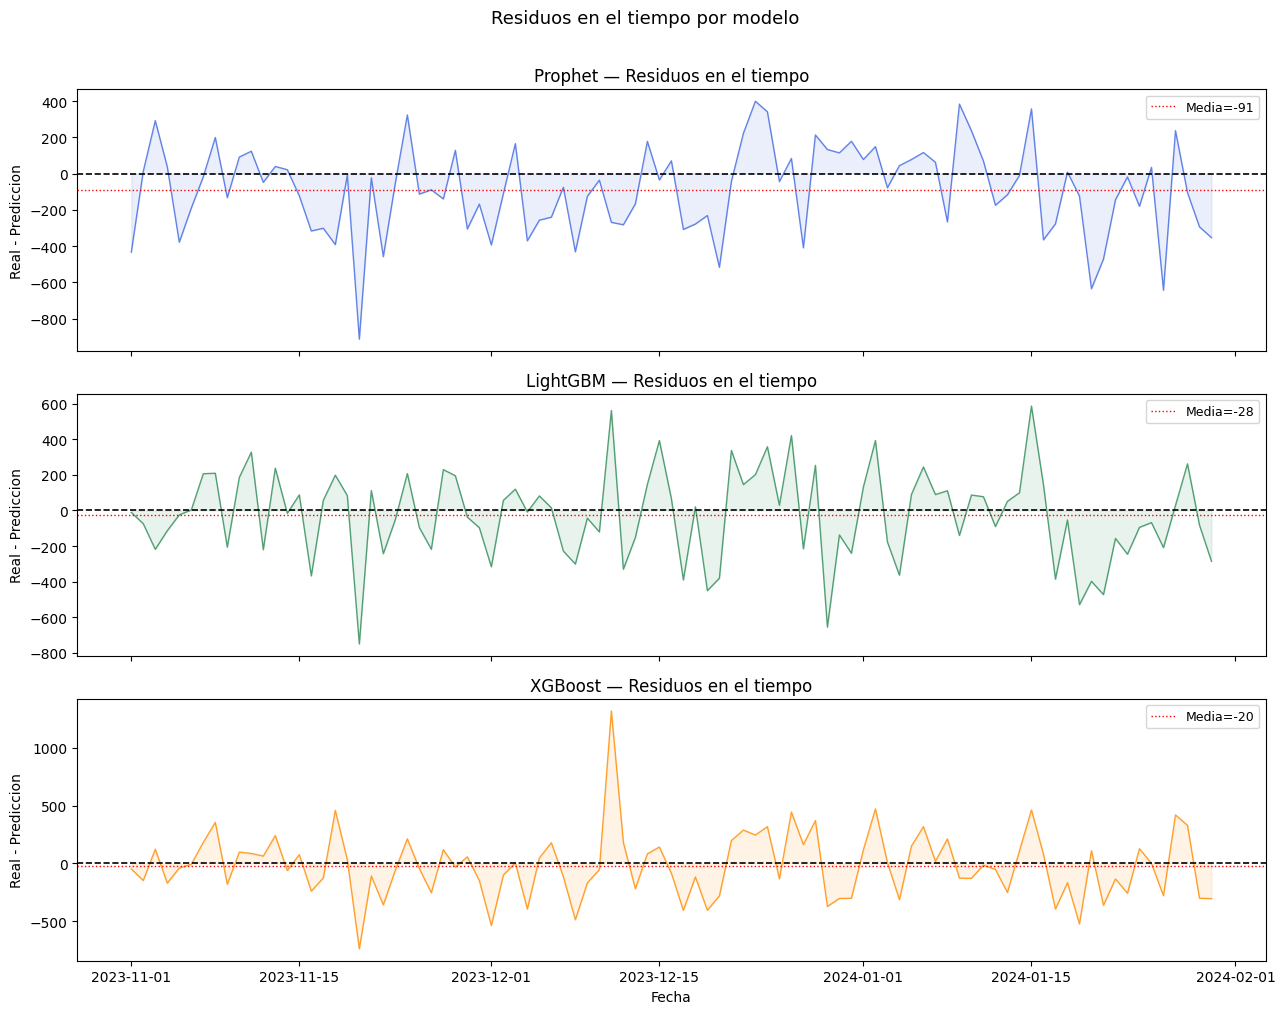

In [171]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
colors = ['royalblue', 'seagreen', 'darkorange']
models = ['Prophet', 'LightGBM', 'XGBoost']

for ax, model, color in zip(axes, models, colors):
    resid = residuals[f'resid_{model}']
    ax.plot(residuals['Date'], resid, color=color, alpha=0.8, linewidth=1)
    ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
    ax.axhline(resid.mean(), color='red', linewidth=1, linestyle=':', label=f'Media={resid.mean():.0f}')
    ax.fill_between(residuals['Date'], resid, 0, alpha=0.1, color=color)
    ax.set_title(f'{model} — Residuos en el tiempo')
    ax.set_ylabel('Real - Prediccion')
    ax.legend(fontsize=9)

axes[-1].set_xlabel('Fecha')
plt.suptitle('Residuos en el tiempo por modelo', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

### 8.3 Autocorrelación de residuos (ACF) + Test de Ljung-Box
Si el ACF tiene barras fuera de la banda azul → hay autocorrelación → los lags no son suficientes.  
El test de Ljung-Box formaliza esto: **p-value > 0.05** → residuos son ruido blanco (ideal).

=== TEST DE LJUNG-BOX (lag=10) ===
Modelo         Estadistico     p-value  Conclusion
------------------------------------------------------------
Prophet              11.34      0.3318  Ruido blanco ✓
LightGBM              4.21      0.9372  Ruido blanco ✓
XGBoost              11.07      0.3521  Ruido blanco ✓


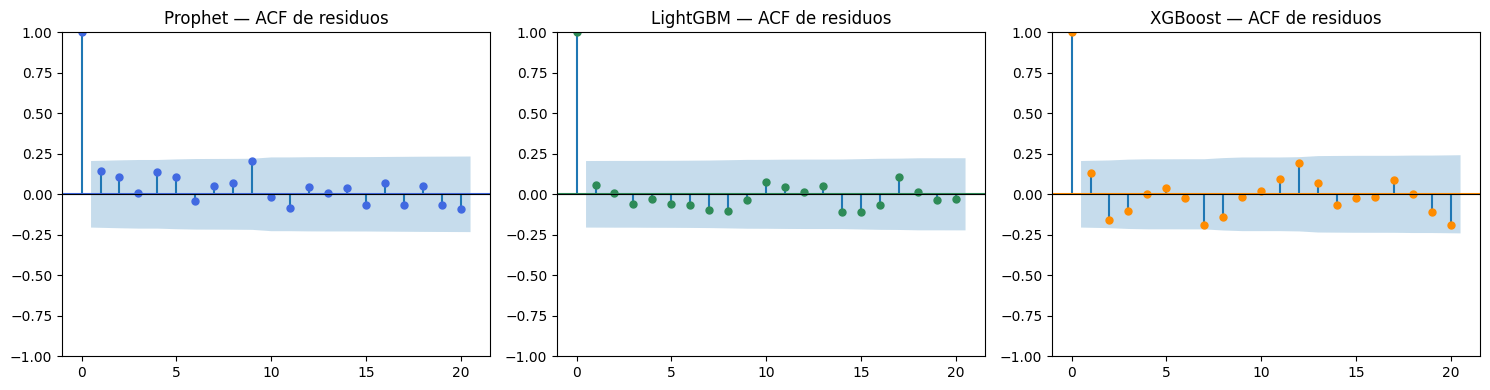

In [172]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

print('=== TEST DE LJUNG-BOX (lag=10) ===')
print(f'{"Modelo":<12}  {"Estadistico":>12}  {"p-value":>10}  {"Conclusion"}')
print('-' * 60)

for ax, model, color in zip(axes, models, colors):
    resid = residuals[f'resid_{model}'].values
    plot_acf(resid, lags=20, ax=ax, color=color, title=f'{model} — ACF de residuos')
    ax.axhline(0, color='black', linewidth=0.8)

    lb = acorr_ljungbox(resid, lags=[10], return_df=True)
    stat   = lb['lb_stat'].values[0]
    pvalue = lb['lb_pvalue'].values[0]
    conclusion = 'Ruido blanco ✓' if pvalue > 0.05 else 'Autocorrelacion detectada ✗'
    print(f'{model:<12}  {stat:>12.2f}  {pvalue:>10.4f}  {conclusion}')

plt.tight_layout(); plt.show()

### 8.4 Residuos vs variables clave
Si los residuos tienen un patrón sistemático contra una variable → el modelo no capturó bien ese efecto.

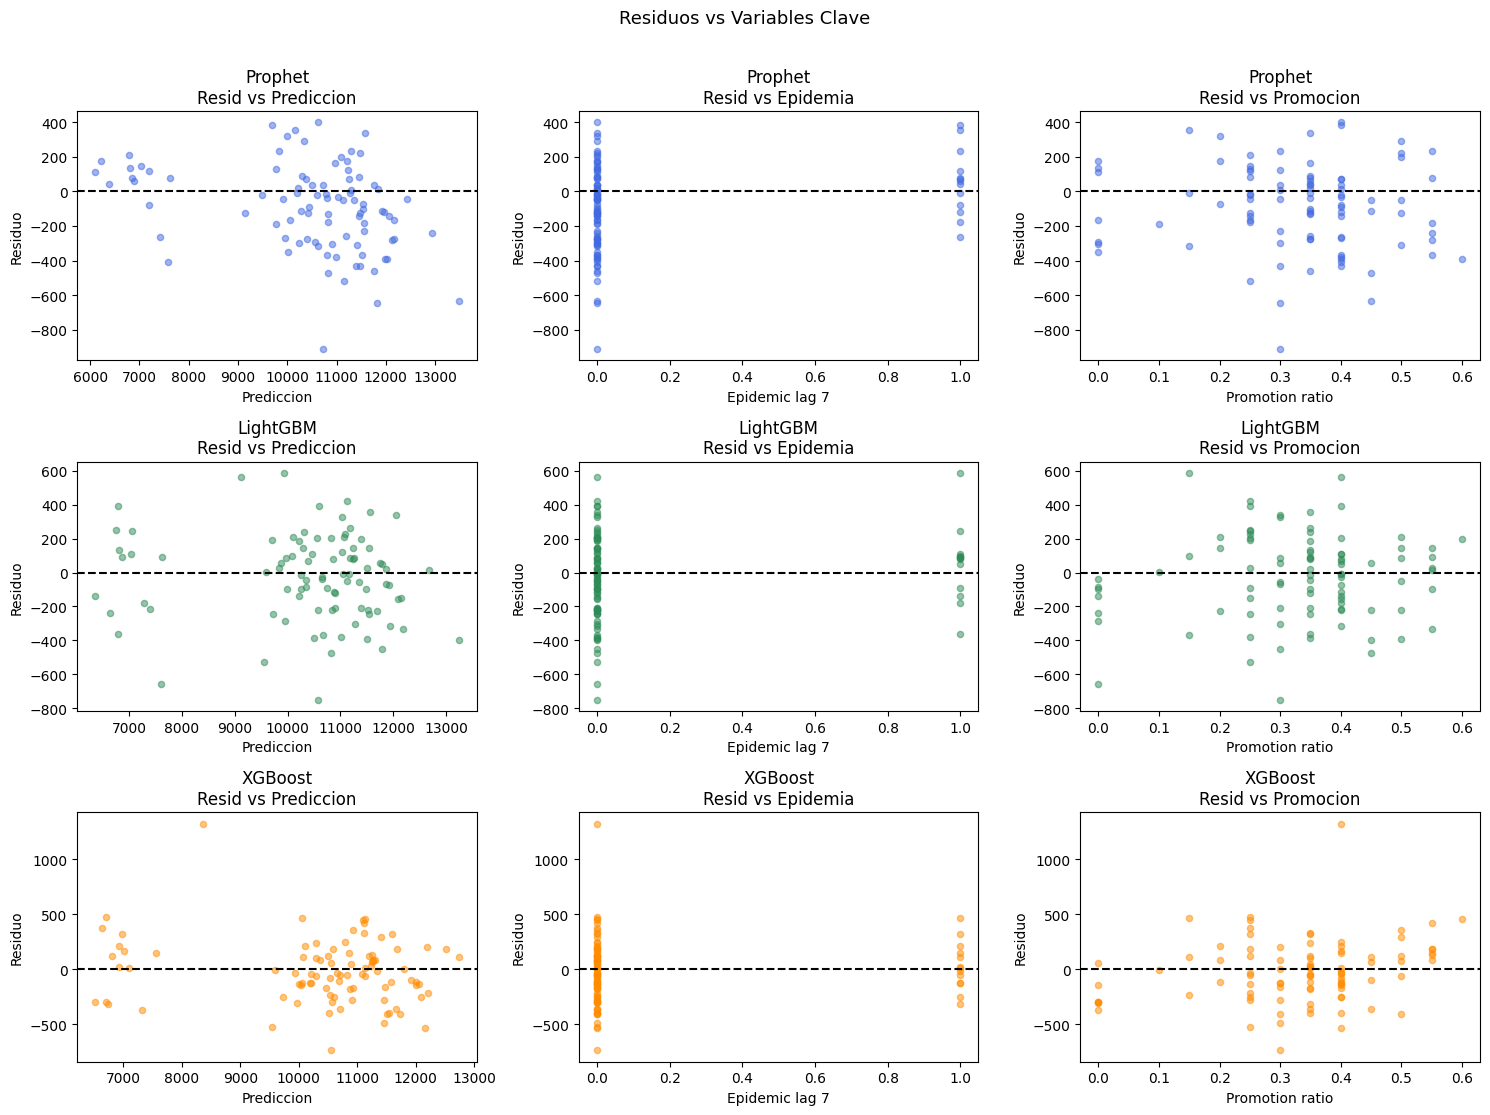

In [173]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
features_to_check = {
    'Prediccion':      ['Prophet', 'LightGBM', 'XGBoost'],
    'Epidemic lag_7':  'epidemic_lag_7',
    'Promo ratio':     'Promotion_Ratio',
}

for col, (model, color) in enumerate(zip(models, colors)):
    resid = residuals[f'resid_{model}']

    # Residuos vs prediccion (homocedasticidad: la varianza no debe crecer con la prediccion)
    axes[col][0].scatter(residuals[model], resid, alpha=0.5, color=color, s=20)
    axes[col][0].axhline(0, color='black', linestyle='--')
    axes[col][0].set_xlabel('Prediccion'); axes[col][0].set_ylabel('Residuo')
    axes[col][0].set_title(f'{model}\nResid vs Prediccion')

    # Residuos vs epidemic_lag_7
    axes[col][1].scatter(residuals['epidemic_lag_7'], resid, alpha=0.5, color=color, s=20)
    axes[col][1].axhline(0, color='black', linestyle='--')
    axes[col][1].set_xlabel('Epidemic lag 7'); axes[col][1].set_ylabel('Residuo')
    axes[col][1].set_title(f'{model}\nResid vs Epidemia')

    # Residuos vs Promotion
    axes[col][2].scatter(residuals['Promotion_Ratio'], resid, alpha=0.5, color=color, s=20)
    axes[col][2].axhline(0, color='black', linestyle='--')
    axes[col][2].set_xlabel('Promotion ratio'); axes[col][2].set_ylabel('Residuo')
    axes[col][2].set_title(f'{model}\nResid vs Promocion')

plt.suptitle('Residuos vs Variables Clave', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

### 8.5 Distribución de residuos
Idealmente centrada en 0 y simétrica. Sesgo positivo → modelo subestima sistemáticamente. Sesgo negativo → sobreestima.

=== DISTRIBUCION DE RESIDUOS ===
Modelo           Media       Std      Skew   Shapiro p  Conclusion
----------------------------------------------------------------------
Prophet          -90.6     248.7    -0.422      0.3662  Normal ✓
LightGBM         -28.0     255.5    -0.207      0.9207  Normal ✓
XGBoost          -20.5     290.0     0.939      0.0010  No normal ✗


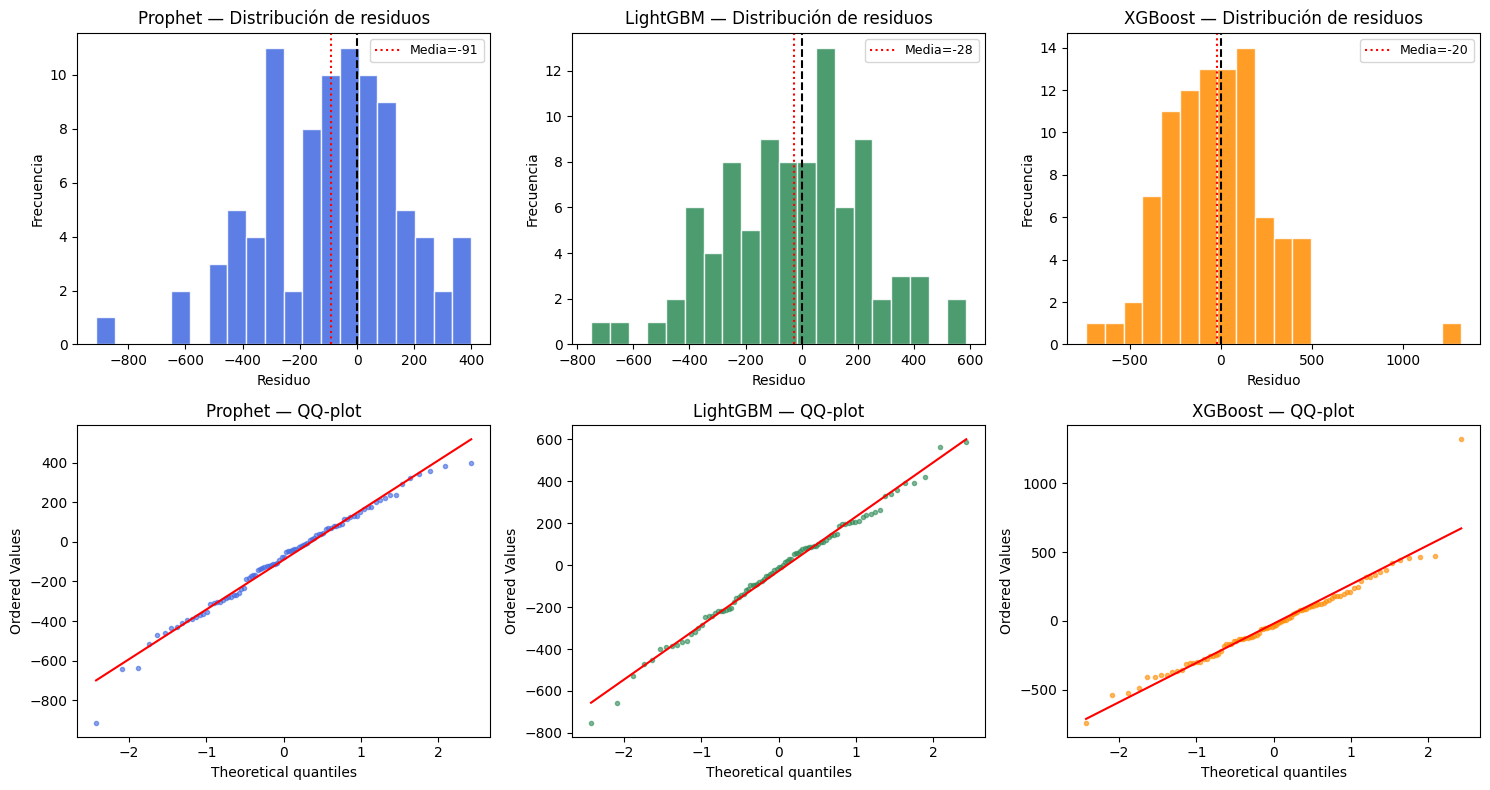

In [174]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

print('=== DISTRIBUCION DE RESIDUOS ===')
print(f'{"Modelo":<12}  {"Media":>8}  {"Std":>8}  {"Skew":>8}  {"Shapiro p":>10}  {"Conclusion"}')
print('-' * 70)

for i, (model, color) in enumerate(zip(models, colors)):
    resid = residuals[f'resid_{model}']

    # Histograma
    axes[0][i].hist(resid, bins=20, color=color, edgecolor='white', alpha=0.85)
    axes[0][i].axvline(0, color='black', linestyle='--', linewidth=1.5)
    axes[0][i].axvline(resid.mean(), color='red', linestyle=':', linewidth=1.5,
                       label=f'Media={resid.mean():.0f}')
    axes[0][i].set_title(f'{model} — Distribución de residuos')
    axes[0][i].set_xlabel('Residuo'); axes[0][i].set_ylabel('Frecuencia')
    axes[0][i].legend(fontsize=9)

    # QQ-plot
    probplot(resid, plot=axes[1][i])
    axes[1][i].set_title(f'{model} — QQ-plot')
    axes[1][i].get_lines()[0].set(color=color, markersize=3, alpha=0.6)

    # Shapiro-Wilk
    stat, pval = shapiro(resid)
    skewness   = float(pd.Series(resid).skew())
    conclusion = 'Normal ✓' if pval > 0.05 else 'No normal ✗'
    print(f'{model:<12}  {resid.mean():>8.1f}  {resid.std():>8.1f}  {skewness:>8.3f}  {pval:>10.4f}  {conclusion}')

plt.tight_layout(); plt.show()

### 8.6 Interpretación del análisis de ruido

**Cómo leer los resultados:**

| Gráfico / Test | Resultado ideal | Problema si... |
|---|---|---|
| Residuos en el tiempo | Nube aleatoria alrededor del 0 | Hay ciclos visibles, tendencia, o cambios de nivel bruscos |
| ACF | Todas las barras dentro de la banda azul | Barras fuera de banda en lags 1, 7 o 14 → falta lag o señal periódica |
| Ljung-Box p-value | > 0.05 | < 0.05 → autocorrelación significativa, el modelo pierde información temporal |
| Resid vs Prediccion | Nube horizontal sin forma | Embudo (más varianza con predicciones altas) → heterocedasticidad |
| Resid vs Epidemia | Media similar en 0 y 1 | Media muy diferente → epidemia mal modelada |
| Resid vs Promocion | Sin patrón | Residuos más altos con promoción → efecto de promo subestimado |
| Distribución | Centrada en 0, simétrica | Media alejada de 0 → sesgo sistemático |
| QQ-plot | Puntos sobre la línea | Colas pesadas → el modelo falla en valores extremos |

**Acciones correctivas según el problema:**
- **Autocorrelación en lag 1** → agregar `lag_1` si no está, o revisar si el lag captura bien el patrón
- **Autocorrelación en lag 7** → el patrón semanal no está bien capturado
- **Sesgo positivo (subestima)** → el modelo es conservador; considerar ajustar con un factor de corrección
- **Heterocedasticidad** → transformación del target (log1p ya aplicada) o modelo de varianza variable
- **Colas pesadas en QQ** → los outliers del período de test no están en el train; considerar datos de mayor cobertura